In [2]:
import pandas as pd
import os
import numpy as np
import pickle
import seaborn as sb
from scipy.stats import pearsonr, ttest_rel, ttest_1samp
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import SensoriMotorPrediction.globals as gl
from SensoriMotorPrediction.vis import plot_binned_cue, plot_rdm, plot_linear_model
from SensoriMotorPrediction.force import calc_G_force
from SensoriMotorPrediction.util import upper_noise_ceiling, lower_noise_ceiling
import PcmPy as pcm
import pingouin as pg

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: atlases


# Finger pre-activation (Fig. R1a)


RM-ANOVA for thumb
  Source        SS  DF        MS         F     p-unc      ng2       eps
0    cue  0.004042   4  0.001011  1.123331  0.355642  0.00334  0.832638
1  Error  0.046779  52  0.000900       NaN       NaN      NaN       NaN

RM-ANOVA for index
  Source        SS  DF        MS         F     p-unc      ng2       eps
0    cue  0.046056   4  0.011514  8.315492  0.000029  0.06841  0.472629
1  Error  0.072002  52  0.001385       NaN       NaN      NaN       NaN

RM-ANOVA for middle
  Source        SS  DF        MS         F    p-unc       ng2       eps
0    cue  0.003064   4  0.000766  0.328446  0.85761  0.001431  0.678388
1  Error  0.121275  52  0.002332       NaN      NaN       NaN       NaN

RM-ANOVA for ring
  Source        SS  DF        MS         F     p-unc       ng2       eps
0    cue  0.034885   4  0.008721  6.281116  0.000335  0.033626  0.773713
1  Error  0.072201  52  0.001388       NaN       NaN       NaN       NaN

RM-ANOVA for pinkie
  Source        SS  DF        MS

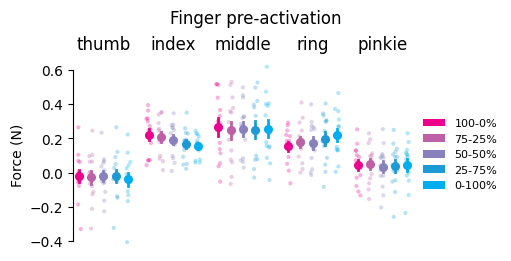

In [3]:
behav = pd.read_csv(os.path.join('data', 'behavioural', 'behaviour.trial.tsv'), sep='\t')
N = behav.sn.nunique()
behav_cue_avg = behav.groupby(['sn', 'cue']).mean(numeric_only=True).reset_index()
fig, axs = plt.subplots(1, 5, sharey=True, figsize=(5, 2.5), constrained_layout=True)
for f, finger in enumerate(gl.fingers):
    ax = axs[f]
    plot_binned_cue(fig, ax, behav_cue_avg, y=f'{finger}0', x='cue', show_individuals=True)
    ax.legend(frameon=False) if f<4 else None
    ax.spines[['left']].set_visible(False)
    ax.tick_params(left=False)
    ax.set_title(finger)
axs[0].tick_params(left=True)
axs[0].spines[['left']].set_visible(True)
axs[0].spines[['left']].set_bounds(-.4, .6)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Finger pre-activation')
fig.savefig(os.path.join('figures', 'preactivation.force.pdf'))
for finger in gl.fingers:
    dv = f'{finger}0'
    aov = pg.rm_anova(
        data=behav_cue_avg,
        dv=dv,
        within='cue',
        subject='sn',
        detailed=True
    )
    print(f'\nRM-ANOVA for {finger}')
    print(aov)
plt.show()

# Regressing out the pre-activation geometry

SMA: tval=2.887, pval=0.006
PMd: tval=4.682, pval=0.000
PMv: tval=3.494, pval=0.002
M1: tval=3.975, pval=0.001
S1: tval=4.531, pval=0.000
SPLa: tval=3.977, pval=0.001
SPLp: tval=5.146, pval=0.000


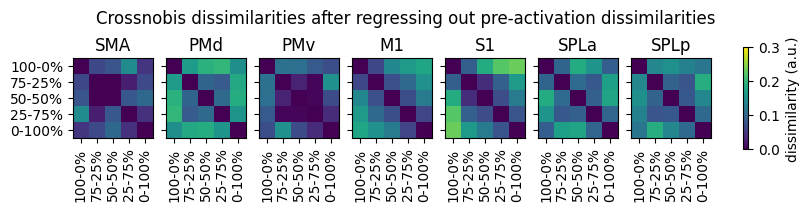

In [4]:
H = 'L'
rois = gl.rois['ROI']
glm = 12

behav_block_cue = behav.groupby(['sn', 'BN', 'cue']).mean(numeric_only=True).reset_index()
G_force, _ = calc_G_force(behav_block_cue, prewhiten=False)
D_force = pcm.G_to_dist(G_force)

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
vmin, vmax = 0, .3
D_res = np.zeros((len(rois), N, 5, 5))
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D_bold = pcm.G_to_dist(G)
    D = D_bold.reshape(-1, 25)
    D_res_roi = np.zeros_like(D)
    for i in range(D.shape[0]):
        X = np.c_[np.ones(D.shape[1]), D_force.reshape(-1, 25)[i]]
        W = np.linalg.pinv(X) @ D[i]
        D_hat = X[:, 1] * W[1]
        D_res_roi[i] = D[i] - D_hat
    D_res_roi = D_res_roi.reshape(-1, 5, 5)
    D_res[r] = D_res_roi
    plot_rdm(fig, axs, r, D_res_roi, gl.cues, vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle(f'Crossnobis dissimilarities after regressing out pre-activation dissimilarities')
fig.savefig(os.path.join('figures', 'crossnobis.plan.preactivation_geom_out.pdf'))
plt.show()


SMA, expectation: rho=0.103, t-test against 0: t=1.960, p=0.036; t-test against lower noise ceiling: t=-4.032, p=0.001
SMA, uncertainty: rho=0.315, t-test against 0: t=4.113, p=0.001; t-test against lower noise ceiling: t=-0.018, p=0.493
PMd, expectation: rho=0.164, t-test against 0: t=2.745, p=0.008; t-test against lower noise ceiling: t=-3.087, p=0.004
PMd, uncertainty: rho=0.379, t-test against 0: t=3.560, p=0.002; t-test against lower noise ceiling: t=0.292, p=0.613
PMv, expectation: rho=0.077, t-test against 0: t=0.908, p=0.190; t-test against lower noise ceiling: t=-2.809, p=0.007
PMv, uncertainty: rho=0.315, t-test against 0: t=2.952, p=0.006; t-test against lower noise ceiling: t=-0.001, p=0.500
M1, expectation: rho=0.305, t-test against 0: t=2.970, p=0.005; t-test against lower noise ceiling: t=0.597, p=0.720
M1, uncertainty: rho=0.097, t-test against 0: t=1.341, p=0.101; t-test against lower noise ceiling: t=-2.029, p=0.032
S1, expectation: rho=0.555, t-test against 0: t=8.05

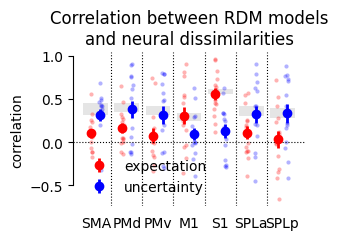

In [11]:
f = open(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'M.plan.p'), "rb")
M = pickle.load(f)
Gc = M[3].Gc

mask = np.triu(np.zeros_like(Gc[0]) + 1, k=1).astype(bool)

D_exp = pcm.G_to_dist(Gc[0])[None, mask]
D_unc = pcm.G_to_dist(Gc[1])[None, mask]

corr_exp = np.zeros((len(rois), N))
corr_unc = np.zeros_like(corr_exp)
ceil_upper = np.zeros_like(corr_exp)
ceil_lower = np.zeros_like(corr_exp)
for r, roi in enumerate(rois):
    D = D_res[r][:, mask]
    ceil_upper[r] = upper_noise_ceiling(D)
    ceil_lower[r] = lower_noise_ceiling(D)
    corr_exp[r] = np.corrcoef(np.r_[D_exp, D])[0, 1:]
    corr_unc[r] = np.corrcoef(np.r_[D_unc, D])[0, 1:]

fig, ax = plt.subplots(figsize=(3, 2))

width = 0.3
x = np.arange(len(rois))

rng = np.random.default_rng(0)
jitter = 0.05

for n in range(N):
    ax.plot(x - width/2 + rng.uniform(-jitter, jitter, len(rois)), corr_exp[:, n], color='r', alpha=0.3, lw=0, marker='o', ms=3, markeredgecolor='none')
    ax.plot(x + width/2 + rng.uniform(-jitter, jitter, len(rois)), corr_unc[:, n], color='b', alpha=0.3, lw=0, marker='o', ms=3, markeredgecolor='none')

ax.errorbar(x - width/2, corr_exp.mean(axis=1), yerr=corr_exp.std(axis=1) / np.sqrt(N), color='r', label='expectation', lw=2, ls='none', marker='o')
ax.errorbar(x + width/2, corr_unc.mean(axis=1), yerr=corr_unc.std(axis=1) / np.sqrt(N), color='b', label='uncertainty', lw=2, ls='none', marker='o')
ax.set_xticks(x)
ax.set_xticklabels(rois)
ax.legend(frameon=False)

ceil_lower_mean = ceil_lower.mean(axis=1)
ceil_upper_mean = ceil_upper.mean(axis=1)

sep = [.5, 1.5, 2.5, 3.5, 4.5, 5.5]

for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')

bar_width = 0.8
for r, roi in enumerate(rois):
    ttest_dep_exp = ttest_rel(corr_exp[r], ceil_lower[r], alternative='less')
    ttest_one_exp = ttest_1samp(corr_exp[r], 0, alternative='greater')
    ttest_dep_unc = ttest_rel(corr_unc[r], ceil_lower[r], alternative='less')
    ttest_one_unc = ttest_1samp(corr_unc[r], 0, alternative='greater')
    print(f'{roi}, expectation: rho={corr_exp.mean(axis=1)[r]:.03f}, t-test against 0: t={ttest_one_exp.statistic:.03f}, p={ttest_one_exp.pvalue:.03f}; t-test against lower noise ceiling: t={ttest_dep_exp.statistic:.03f}, p={ttest_dep_exp.pvalue:.03f}')
    print(f'{roi}, uncertainty: rho={corr_unc.mean(axis=1)[r]:.03f}, t-test against 0: t={ttest_one_unc.statistic:.03f}, p={ttest_one_unc.pvalue:.03f}; t-test against lower noise ceiling: t={ttest_dep_unc.statistic:.03f}, p={ttest_dep_unc.pvalue:.03f}')
    ax.fill_between(
        [r - bar_width / 2, r + bar_width / 2],
        ceil_lower_mean[r],
        ceil_upper_mean[r],
        color='grey', alpha=0.2, lw=0)

ax.set_ylabel('correlation')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines[['left']].set_bounds(-.5, 1)
#ax.set_ylim(-.15, .6)
ax.set_xlabel('')
ax.axhline(0, ls=':', color='k', lw=.8)
ax.tick_params(axis='x', bottom=False,)
ax.set_title('Correlation between RDM models\nand neural dissimilarities')
fig.savefig(os.path.join('figures', 'correlation.model_neural.pdf'))
plt.show()

# Regressing out finger pre-activation from 1st-level GLM coefficients


Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=1.926, pval=0.038
PMd: tval=3.482, pval=0.002
PMv: tval=3.139, pval=0.004
M1: tval=3.492, pval=0.002
S1: tval=4.190, pval=0.001
SPLa: tval=3.407, pval=0.002
SPLp: tval=4.142, pval=0.001


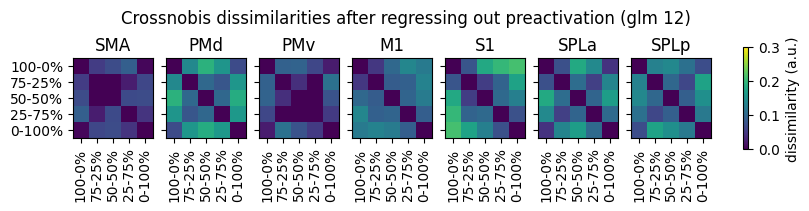

In [23]:
fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
vmin, vmax = 0, .3
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ols.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    plot_rdm(fig, axs, r, D, gl.cues, vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle(f'Crossnobis dissimilarities after regressing out preactivation (glm {glm})')
fig.savefig(os.path.join('figures', 'crossnobis.plan.preactivation_out.pdf'))
plt.show()

In [24]:
for r, roi in enumerate(rois):
    # original
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D_ori = pcm.G_to_dist(G)[:, mask]
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.ols.glm{glm}.{H}.{roi}.npy'))
    D_ols = pcm.G_to_dist(G)[:, mask]
    D_rdm = D_res[r][:, mask]

    corr_rdm = np.diag(np.corrcoef(np.r_[D_rdm, D_ori])[:N, N:])
    corr_ols = np.diag(np.corrcoef(np.r_[D_ols, D_ori])[:N, N:])

    ttest_one = ttest_1samp(corr_rdm, 0, alternative='greater')
    print(f'{roi}: rho (rdm)={corr_rdm.mean():.03f}, t-test against 0: t={ttest_one.statistic:.03f}, p={ttest_one.pvalue:.03f}')
    
    ttest_one = ttest_1samp(corr_ols, 0, alternative='greater')
    print(f'{roi}: rho (ols)={corr_ols.mean():.03f}, t-test against 0: t={ttest_one.statistic:.03f}, p={ttest_one.pvalue:.03f}')

SMA: rho (rdm)=0.946, t-test against 0: t=60.209, p=0.000
SMA: rho (ols)=0.828, t-test against 0: t=10.895, p=0.000
PMd: rho (rdm)=0.953, t-test against 0: t=77.367, p=0.000
PMd: rho (ols)=0.851, t-test against 0: t=14.381, p=0.000
PMv: rho (rdm)=0.913, t-test against 0: t=30.171, p=0.000
PMv: rho (ols)=0.864, t-test against 0: t=15.452, p=0.000
M1: rho (rdm)=0.898, t-test against 0: t=22.102, p=0.000
M1: rho (ols)=0.795, t-test against 0: t=7.555, p=0.000
S1: rho (rdm)=0.789, t-test against 0: t=10.196, p=0.000
S1: rho (ols)=0.770, t-test against 0: t=6.011, p=0.000
SPLa: rho (rdm)=0.964, t-test against 0: t=72.524, p=0.000
SPLa: rho (ols)=0.873, t-test against 0: t=16.741, p=0.000
SPLp: rho (rdm)=0.917, t-test against 0: t=44.210, p=0.000
SPLp: rho (ols)=0.834, t-test against 0: t=11.084, p=0.000


                           T     p-val
roi  method                           
M1   ols    T-test  1.755221  0.051371
     raw    T-test  2.446785  0.014695
PMd  ols    T-test  2.017817  0.032369
     raw    T-test  3.697104  0.001342
PMv  ols    T-test  0.833742  0.209741
     raw    T-test  1.618486  0.064776
S1   ols    T-test  2.795206  0.007584
     raw    T-test  3.397400  0.002383
SMA  ols    T-test  0.773872  0.226425
     raw    T-test  1.081856  0.149488
SPLa ols    T-test  1.883373  0.041107
     raw    T-test  3.034924  0.004787
SPLp ols    T-test  2.135814  0.026146
     raw    T-test  3.251405  0.003156


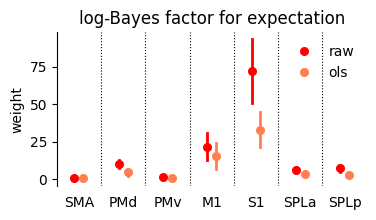

In [25]:
comp_model = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, 'component_model.BOLD.tsv'), sep='\t')
comp_model = comp_model[(comp_model.epoch=='plan') & (comp_model.glm==glm) & (comp_model.Hem==H)].reset_index()
comp_model['norm_weight'] = np.sqrt(comp_model['weight'] / comp_model['noise'])
comp_model_exp = comp_model[comp_model.component=='expectation']
comp_model_unc = comp_model[comp_model.component=='uncertainty']

fig, ax = plt.subplots(figsize=(4, 2))
sb.pointplot(ax=ax, data=comp_model_exp, x='roi', y='BF', hue='method', palette=['red', 'coral'], errorbar='se', linestyles='none', dodge=.2, lw=2)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
#ax.spines[['left']].set_bounds(0, 40)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor for expectation')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
ttest = comp_model_exp.groupby(['roi', 'method']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
print(ttest[['T', 'p-val', ]])
plt.show()

                           T     p-val
roi  method                           
M1   ols    T-test  1.570054  0.070207
     raw    T-test  1.420972  0.089433
PMd  ols    T-test  2.249855  0.021209
     raw    T-test  2.108148  0.027496
PMv  ols    T-test  2.156136  0.025194
     raw    T-test  2.124096  0.026710
S1   ols    T-test  2.400820  0.016018
     raw    T-test  2.164677  0.024804
SMA  ols    T-test  1.600291  0.066772
     raw    T-test  1.570233  0.070186
SPLa ols    T-test  1.750278  0.051809
     raw    T-test  1.675392  0.058864
SPLp ols    T-test  3.118166  0.004078
     raw    T-test  2.985036  0.005269


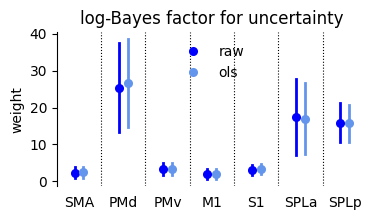

In [26]:
fig, ax = plt.subplots(figsize=(4, 2))
sb.pointplot(ax=ax, data=comp_model_unc, x='roi', y='BF', hue='method', palette=['blue', 'cornflowerblue'], errorbar='se', linestyles='none', lw=2, dodge=.2)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
#axs[0].spines[['left']].set_bounds(0, 30)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor for uncertainty')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
ttest = comp_model_unc.groupby(['roi', 'method']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
print(ttest[['T', 'p-val']])
plt.show()

               T     p-unc
roi                       
M1   0 -1.638940  0.062594
PMd  0 -2.533299  0.012484
PMv  0 -2.383504  0.016545
S1   0 -1.861007  0.042753
SMA  0 -0.458903  0.326941
SPLa 0 -1.632065  0.063320
SPLp 0 -2.450897  0.014582


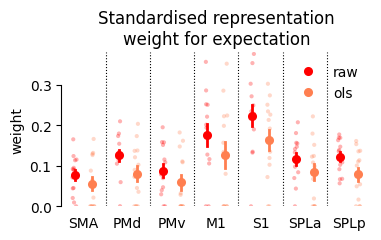

In [27]:
fig, ax = plt.subplots(figsize=(4, 2))
sb.pointplot(ax=ax, data=comp_model_exp, x='roi', y='norm_weight', hue='method', palette=['red', 'coral'], errorbar='se', linestyles='none', lw=2, dodge=.4)
sb.stripplot(ax=ax, data=comp_model_exp, x='roi', y='norm_weight', hue='method', size=3, palette=['red', 'coral'], jitter=.1, dodge=True, legend=False, alpha=.3)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines[['left']].set_bounds(0, .3)
ax.set_ylim(0, .38)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation\nweight for expectation')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
ttest = comp_model_exp.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='method', subject='participant_id', alternative='less'))
print(ttest[['T', 'p-unc']])
fig.savefig(os.path.join('figures', 'weight.plan.preact_out.expectation.pdf'))
plt.show()